# Chapter 5 — Transformers: Self-Attention (Theory Only, Bootcamp Collab Notes)

## 0) Why we moved from RNN/LSTM to Transformers
RNNs and LSTMs read text **sequentially (word by word)**. This creates 3 real problems in practice:
1) **Sequential bottleneck (slow):** cannot fully parallelize training on GPUs → training becomes slower as text length grows  
2) **Long-range dependency weakness:** even LSTM/GRU struggle to reliably keep information from very far tokens (context fades)  
3) **Global context is hard:** understanding often needs linking distant words (coreference, dependencies, overall meaning)

✅ Transformers were introduced to solve this by using **Self-Attention**:
- Each token can directly look at every other token
- Training becomes parallel and scalable
- Better at capturing global meaning across long text

---

## 1) What is Self-Attention? (Core Definition)
**Self-Attention** is a mechanism where each word/token in a sentence decides:
> “Which other words in this sentence are important for me to understand my meaning?”

So for every token, the model assigns **attention weights** to all tokens (including itself), and then builds a new representation using the most relevant ones.

---

## 2) Human Intuition (How to explain to learners)
Humans don’t understand a sentence by only looking at the previous word.
We constantly relate words across the entire sentence.

Example:
“The animal didn’t cross the road because it was tired.”

To understand “it”, we connect it back to the correct word.
Self-attention enables the model to create this kind of connection.

---

## 3) What problem does Self-Attention solve?
### (A) Global context in one step
Instead of passing information step-by-step (like RNN), attention can connect:
- first word ↔ last word
- pronoun ↔ noun
- cause ↔ effect  
… instantly through weighted links.

### (B) Parallel training
Self-attention computes relationships across the entire sequence **at once**, which is GPU-friendly.

---

## 4) The Three Vectors: Query, Key, Value (Q, K, V) — High-level
To compute attention, every token is converted into 3 vectors:

### ✅ Query (Q) — "What am I looking for?"
Each token asks a question:  
> “What type of information do I need from other tokens?”

### ✅ Key (K) — "What do I offer?"
Each token describes itself:
> “Here’s what I contain; match me if relevant.”

### ✅ Value (V) — "What information do I pass?"
This is the actual information that gets shared if attended to:
> “If you focus on me, this is what you’ll take from me.”

**Important learner point:**  
Q/K are used to compute relevance (scores), V is what gets combined to form output.

---

## 5) Attention Weights — What actually happens conceptually?
For each token:
1) Compare its **Query** with every token’s **Key**
2) This produces a relevance score for each pair  
3) Convert scores into **weights** (so they sum to 1)
4) Use these weights to take a weighted mix of the **Values**

So the output for a token becomes:
> “A smart mixture of information from all tokens, based on relevance.”

---

## 6) What does the model learn using self-attention?
Self-attention heads learn patterns like:
- subject ↔ verb links  
- pronoun ↔ noun reference (it → animal)  
- keyword ↔ meaning emphasis  
- negation handling (“not”)  
- cause-effect relations (“because”)  
- entity relationships (person ↔ place)

This is why Transformers became superior for language.

---

## 7) Multi-Head Attention (Concept Only)
Instead of doing attention once, Transformers do it multiple times in parallel using **multiple heads**.

Each head can learn a different type of relationship:
- Head 1: grammar/syntax
- Head 2: entity reference
- Head 3: semantic meaning
- Head 4: long-range dependency

Then all heads are combined to form the final representation.

✅ Why it matters:
One head alone might miss some relationship.
Multiple heads capture richer language structure.

---

## 8) Why Positional Encoding is needed
Self-attention alone does not know word order because it looks at all tokens together.

So Transformers add **positional information** to token embeddings so the model understands:
- which token came first
- which token came next
- distance between tokens

Without positions:
“dog bites man” and “man bites dog” could look similar.

---

## 9) Self-Attention Summary (Interview ready)
- RNN/LSTM: sequential, slow, long context issues  
- Transformer: parallel and global context  
- Self-attention: each token attends to all others  
- Q, K, V:
  - Q = what I want
  - K = what I am
  - V = what I provide
- Multi-head: multiple relationship views
- Positional encoding: adds order understanding

---

## 10) Transition to Next Topic: Transformer Architecture
Now that Self-Attention is clear, we will build the full Transformer block:
1) Self-Attention layer
2) Feed Forward Network (FFN)
3) Residual connections
4) Layer Normalization
5) Stacking multiple blocks

Then we will map:
- **BERT** = Encoder-only (understanding tasks)
- **GPT** = Decoder-only (text generation)
- **T5** = Encoder-Decoder (translation + multitask)






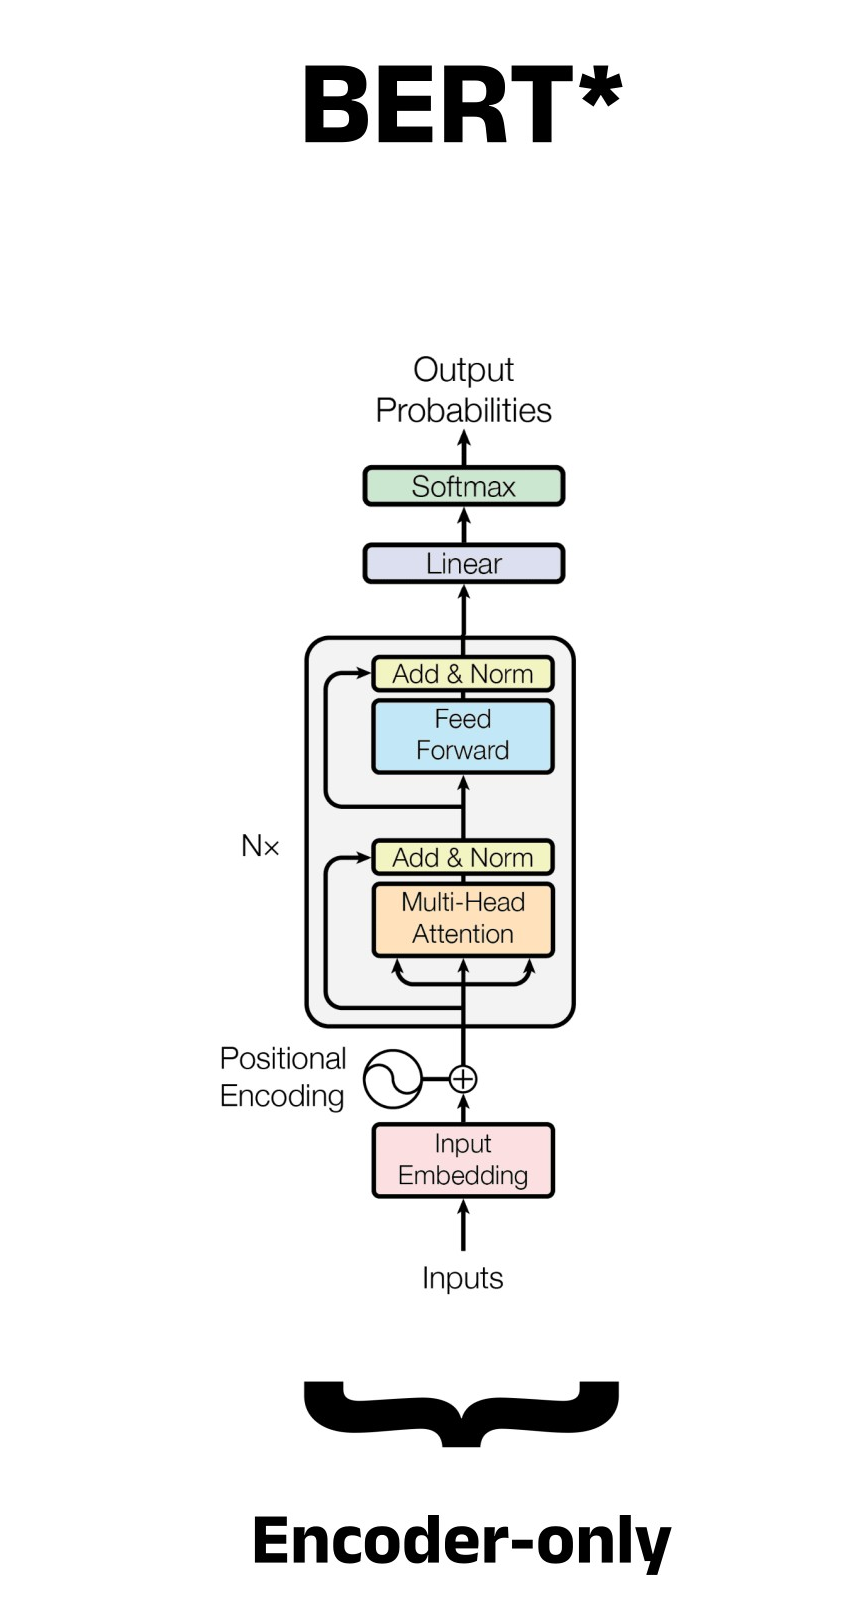

# Chapter 5.3 — Encoder–Decoder Concept (Big Picture)
## Focus: Encoder (Understanding Only)

> Goal of this section: Build a **high-level mental model** of what the encoder does,  
> without going inside the block components yet (that will come in 5.4).

---

## 1) What is the Encoder?
The **Encoder** is the **understanding module** of the Transformer.

It takes an input sentence and produces a **deep, contextual representation** of that sentence.
- It **does not generate text**
- It **does not predict next words**
- Its job is to **understand** the input thoroughly

Think:
✅ Encoder = **Reader / Understanding Brain**  
(Decoder = Writer / Generator — we’ll cover later in 5.5)

---

## 2) What goes into the Encoder?
Before entering the encoder, raw text is converted into numerical form:

### (A) Token Embeddings
Each word/subword token becomes a vector that captures its base meaning.

### (B) Positional Encoding
Because word order matters, we add positional information so the model knows:
- which token came first
- which token came next
- relative distances between tokens

So encoder input is effectively:
**Embedding + Position information**

---

## 3) What does the Encoder actually do (High-level)?
Inside the encoder, each token can look at **all other tokens** in the sentence.

This allows the encoder to learn:
- relationships between words
- long-range dependencies (far-apart words)
- references (e.g., “it” refers to something earlier)
- overall sentence meaning

This is possible because the encoder uses **self-attention** internally.

📌 Important: At this stage, we only need to remember:
> The encoder creates **context-aware representations**.

---

## 4) What comes out of the Encoder?
The encoder outputs:
- a set of vectors (one per token)
- each vector represents the token **with full context**

So the meaning of a token becomes richer:
Example: the word “bank”
- could mean river bank or money bank
- encoder uses surrounding words to decide correct meaning

Output vectors are often called:
✅ **Contextual embeddings / contextual representations**

---

## 5) Why is the Encoder useful?
Because many tasks require understanding, not generation.

Examples:
- text classification (spam vs not spam)
- sentiment analysis (positive/negative)
- search/retrieval understanding
- question answering understanding
- NER (names, locations, dates)

These tasks depend on:
✅ Understanding word meaning **in context**

---

## 6) Encoder in real models (Connection to BERT)
**BERT** is an example of an **encoder-only** Transformer model.

Meaning:
- BERT uses the encoder stack to understand text deeply
- then adds small heads on top for tasks (classification, QA, etc.)

📌 We will cover BERT explicitly in section 5.6.

---

## 7) Diagram Reminder (How to teach with the diagram)
Use the main Transformer diagram and focus ONLY on:
**Inputs → Encoder stack → contextual output vectors**

Ignore decoder blocks for now.

---

## 8) Key takeaway (Memorize)
> **Encoder converts raw input text into deep contextual understanding (vectors).**

---



# Chapter 5.4 — Transformer Encoder Architecture
## (Theory Only — No Math, No Code)

> Goal of this section:  
> Understand **how the encoder internally builds deep understanding** of text by stacking layers and stabilizing learning.

---

## 1) What does “Encoder Architecture” mean?
The encoder is **not a single block**.  
It is a **stack of identical encoder layers**, where each layer improves the representation of the input text.

Each encoder layer has:
- The same structure
- Different learned parameters
- A role in gradually deepening understanding

---

## 2) High-Level Flow Inside the Encoder
For each encoder layer, data flows through:

1. Input Embeddings  
2. Positional Encoding  
3. Self-Attention  
4. Feed Forward Network (FFN)  
5. Residual Connections  
6. Layer Normalization  

This **entire block is repeated multiple times**.

---

## 3) Input Embeddings
- Text is converted into vectors
- Each vector represents a token’s **basic meaning**
- At this stage, vectors are **context-free**

Example:
The word “bank” looks the same whether the sentence talks about a river or money.

---

## 4) Positional Encoding
Self-attention alone does not understand word order.

Positional encoding adds:
- Word position
- Sequence order
- Relative distance between tokens

After this step, each token contains:
> **Meaning + Position**

---

## 5) Self-Attention (Encoder Version)
Self-attention allows:
- Each token to look at **all other tokens**
- The model to decide which tokens are important

This creates **context-aware representations**.

Example:
- “bank” near “river” → river bank  
- “bank” near “money” → financial bank  

Self-attention is the **core intelligence** of the encoder.

---

## 6) Feed Forward Network (FFN)
After self-attention:
- Each token is processed **independently**
- A small neural network refines the token representation

Purpose of FFN:
- Transform features
- Increase expressiveness
- Prepare representations for deeper layers

Think:
> Attention builds relationships, FFN sharpens understanding.

---

## 7) Residual Connections (Skip Connections)
Residual connections mean:
> The input of a layer is **added back** after processing.

Why this is important:
- Prevents loss of original information
- Helps gradients flow easily
- Makes deep stacking possible

Conceptually:
- Old knowledge is preserved
- New knowledge is layered on top

Residual connections are applied:
- After self-attention
- After the FFN

---

## 8) Layer Normalization
Layer normalization:
- Stabilizes values inside the network
- Keeps learning consistent across layers
- Prevents exploding or vanishing activations

Simple rule:
- Residuals preserve information  
- LayerNorm stabilizes learning  

Together, they make training safe and efficient.

---

## 9) Stacking Encoder Layers
The encoder block is repeated multiple times.

Why stacking works:
- Lower layers learn simple relationships
- Middle layers learn grammar and structure
- Higher layers learn meaning and semantics

Each layer:
- Receives the output of the previous layer
- Builds a richer, more abstract representation

This is similar to:
> Reading a sentence multiple times and understanding it better each time.

---

## 10) Why the Encoder Architecture is Powerful
- Captures global context
- Handles long-range dependencies
- Learns deep semantic meaning
- Trains efficiently using parallel computation

This architecture is the foundation of:
- BERT
- Encoder parts of T5
- Modern language understanding systems

---

## 11) Key Takeaway (Memorize)
> **The encoder transforms raw word embeddings into deep, contextual representations by repeatedly applying attention, refinement, and stabilization.**

---



# Chapter 5.3 (Continued) — Encoder–Decoder Concept (Big Picture)
## Focus: Decoder (Generation Only) — Theory Notes (No Math, No Code)

> Goal of this section:  
> Understand what the **Decoder** does at a big-picture level before going inside its architecture (5.5).

---

## 1) What is the Decoder?
The **Decoder** is the **generation module** of the Transformer.

- Encoder = understands input text  
- Decoder = generates output text

The decoder produces output **token by token** (one word/subword at a time).

---

## 2) What is the Decoder’s job?
The decoder is responsible for:
- Generating fluent language
- Maintaining coherence across the output
- Predicting the **next token**
- Producing a complete final answer/translation/response

Important:
✅ Decoder generates text  
❌ Decoder does not “just understand” — it is a generator.

---

## 3) What information does the Decoder use?
The decoder uses two sources:

### (A) Previously generated tokens (output so far)
- The decoder always looks at the tokens it has already generated
- This helps keep grammar and meaning consistent

Example (generation):
"Hello" → "Hello world" → "Hello world today" ...

### (B) Encoder output (context / memory) — only if encoder exists
- In encoder–decoder models, the decoder consults the encoder’s output
- Encoder output contains deep understanding of the input
- This guides what the decoder should generate

So the decoder can be guided by:
- Output-so-far (past tokens)
- Input-understanding (encoder memory)

---

## 4) Why does the Decoder generate step-by-step?
Language generation must:
- Follow word order
- Not “cheat” by seeing future words
- Build meaning progressively

So the decoder predicts:
> the next token given what came before.

This is why output generation is sequential during inference.

---

## 5) Critical rule: Decoder cannot see the future
The decoder is designed so that during generation:
- It can attend only to **past tokens**
- It cannot look at future tokens (tokens not generated yet)

This rule is enforced inside the decoder using a mechanism we will cover in 5.5:
✅ **Masked self-attention**

---

## 6) How Encoder and Decoder connect (High level)
In encoder–decoder models:
1. Encoder reads and understands the full input
2. Decoder generates output while consulting encoder output

Example:
Input: “Translate English to French: I love AI”
- Encoder creates a contextual understanding of the input
- Decoder generates: “J’” → “J’aime” → “J’aime l’IA”

---

## 7) Decoder in real model families
### Encoder–Decoder models (e.g., T5, translation systems)
- Decoder uses:
  - past generated tokens
  - encoder output (input understanding)

### Decoder-only models (e.g., GPT)
- There is no separate encoder
- Decoder generates using:
  - past tokens only
- This is why GPT is great for text generation.

(We will map BERT/GPT/T5 clearly in 5.6.)

---

## 8) Key takeaway (Memorize)
> **Decoder generates output text token by token, guided by past tokens and (optionally) encoder understanding.**

---

## Diagram instruction (for your GoodNotes/Teaching)
Use the main Transformer diagram and focus only on:
- Decoder side (right)
- Output generation flow
Ignore internal blocks for now.

---

✅ Status
5.3 Decoder (Big Picture) — COMPLETED (Theory)

Next:
# 5.5 Transformer Decoder Architecture
We will go inside the decoder and explain:
- masked self-attention
- encoder–decoder attention
- FFN
- residual + layer norm
- next-token prediction flow


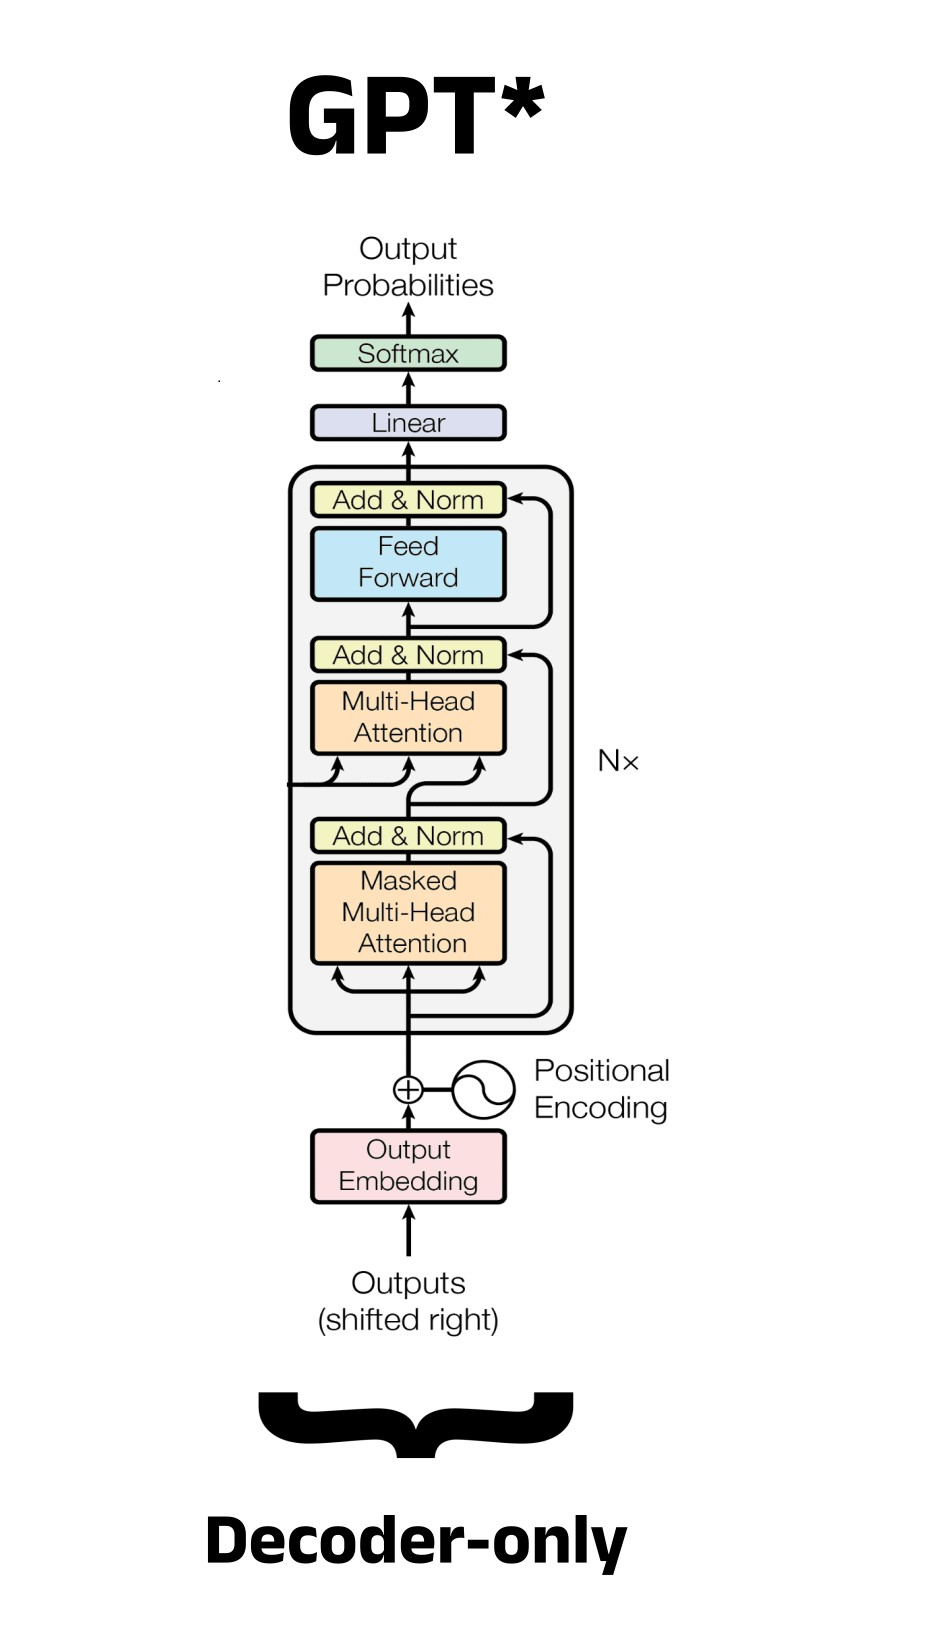

# Chapter 5.5 — Transformer Decoder Architecture
## (Theory Only — No Math, No Code)

> Goal of this section:  
> Understand **how the decoder internally generates text** and what makes it different from the encoder.

---

## 1) What is Decoder Architecture?
The decoder is the part of a Transformer that **generates output text**.

- Encoder = understanding module (reads input)
- Decoder = generation module (writes output)

Decoder generates text **token by token** (one word/subword at a time).

---

## 2) High-Level Structure of a Decoder Layer
Each **decoder layer** contains:

1. **Masked Self-Attention**  ✅ (special for generation)
2. **Encoder–Decoder Attention** ✅ (only when an encoder exists)
3. **Feed Forward Network (FFN)** ✅
4. **Residual Connections + Layer Normalization** ✅ (stability helpers)

This decoder layer is **stacked multiple times** (repeated N times).

---

## 3) Masked Self-Attention (MOST IMPORTANT)
### Why do we need masking?
During generation, the model must not “cheat” by seeing future tokens.

So the decoder is designed so that each position can attend only to:
✅ tokens before it (past tokens)  
❌ not tokens after it (future tokens)

Example sequence being generated:
"I love AI"

- When predicting "love" → it can see "I"
- When predicting "AI" → it can see "I love"
- It can never see future words that are not generated yet

This makes generation valid and realistic.

📌 This masking is why decoder-only models (like GPT) work for next-token prediction.

---

## 4) Encoder–Decoder Attention (Only if Encoder Exists)
This block connects input understanding to output generation.

- Encoder output = deep contextual “memory” of the input
- Decoder queries this memory to decide what part of input matters now

Example (translation):
Input: "I love AI"
Encoder: understands full meaning
Decoder: focuses on relevant parts while generating French output

✅ Used in: Encoder–Decoder models (e.g., T5, translation, summarization)
❌ Not used in: Decoder-only models (GPT has no separate encoder)

---

## 5) Feed Forward Network (FFN)
FFN is applied after attention blocks.

- It processes each token independently
- Refines representations
- Adds more expressive transformation capacity

Simple idea:
> Attention builds relationships, FFN refines the representation.

---

## 6) Residual Connections (Skip Connections)
Residual connections mean:
> add the original input back after each major operation

Why it matters:
- prevents information loss
- improves gradient flow
- makes deep stacking possible
- helps stable training

Residuals are applied around:
- Masked self-attention
- Encoder–decoder attention (if present)
- FFN

---

## 7) Layer Normalization
LayerNorm stabilizes training by:
- keeping values in a healthy range
- improving learning consistency across layers
- preventing exploding/vanishing activations

Rule to remember:
- Residuals preserve information
- LayerNorm stabilizes learning

---

## 8) Stacking Decoder Layers
Decoder layers are repeated multiple times.

Stacking helps the model learn:
- lower layers → simple patterns (local language structure)
- higher layers → fluency, coherence, reasoning

Deep stacking improves:
✅ grammar  
✅ coherence  
✅ long-range dependency handling  
✅ generation quality

---

## 9) Output Generation (High-Level)
After the final decoder layer:
- model produces probabilities over the vocabulary
- selects one token (next token)
- appends it to the sequence
- repeats until completion (end token or stop condition)

This is why output is generated step-by-step.

---

## 10) Decoder-only Models (GPT)
GPT is **decoder-only**:
- no separate encoder
- relies on masked self-attention
- predicts next token using only past tokens

This is why GPT is strong for:
- text generation
- chat responses
- summarization (prompt-based)
- reasoning-style outputs

---

## 11) Key Takeaway (Memorize)
> **Decoder generates text token by token using masked attention, optional encoder context, and stacked layers with residual + layer norm.**




# Chapter 5.7 — Why Transformers Became the Foundation for LLMs


---

## 1) Why earlier models failed to scale
Before Transformers, common sequence models were **RNNs / LSTMs**.

They struggled because:
- They process tokens **sequentially** (one-by-one)
- Training becomes slow as sequence length grows
- Long-range dependencies are hard to maintain
- Not GPU-efficient for massive training

These limitations made it difficult to train **very large language models**.

---

## 2) What Transformers changed (Core Revolution)
Transformers introduced **self-attention**, which allows:
- Each token to look at **all other tokens**
- Global context to be learned directly

Transformers also enabled:
- **Parallel computation** (GPU-friendly)
- **Stable deep networks** (via residual connections + layer normalization)

---

## 3) Parallel training advantage (GPU-friendly & scalable)
In Transformers:
- All tokens in a sequence can be processed **at the same time**
- Computation is highly parallelizable on GPUs

In RNNs:
- Token processing depends on previous token
- Training is slower and harder to parallelize

Result of Transformers:
✅ Faster training  
✅ Better hardware utilization  
✅ Possible to train on huge corpora

---

## 4) Ability to scale with data and parameters
Transformers scale well when we increase:
- Training data
- Number of layers
- Model parameters

This scaling leads to:
- Better language understanding
- Stronger generation quality
- New capabilities (summarization, reasoning, coding, tool use)

---

## 5) One architecture → many capabilities
Transformers support multiple model types:
- Encoder-only (BERT) → understanding tasks
- Decoder-only (GPT) → generation tasks
- Encoder–Decoder (T5) → transformation tasks

Same foundation, different usage pattern.

---

## 6) Why all modern LLMs are Transformer-based
LLMs require:
- Long-context handling
- Deep understanding of relationships in text
- Massive parallel training
- Stable deep stacking of layers

Transformers satisfy all these requirements.

That’s why modern LLM families are built on Transformers.

---

## 7) Connection to Modern GenAI Systems
Transformers now power:
- Chatbots and assistants
- Code generation tools
- Search and retrieval systems
- RAG pipelines (LLM + embeddings + vector DB)
- Agentic workflows (multi-step reasoning + tools)

---

## 8) Key Takeaway (Memorize)
> **Transformers enable parallel, scalable, and context-aware learning — which made LLMs possible.**

---

